In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv("diabetes.csv")

In [ ]:
print("First 10 rows are:")
df.head()

First 10 rows are:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("\n📌 Dataset shape:")
print(df.shape)

print("\n📌 Dataset info:")
print(df.info())

print("\n📌 Statistical summary:")
display(df.describe())

print("\n📌 Missing values:")
print(df.isnull().sum())


📌 Dataset shape:
(768, 9)

📌 Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

📌 Statistical summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



📌 Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("\n📌 Zero values in important columns:")
for col in cols_with_zero:
    print(f"{col}: {df[col].eq(0).sum()}")


📌 Zero values in important columns:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


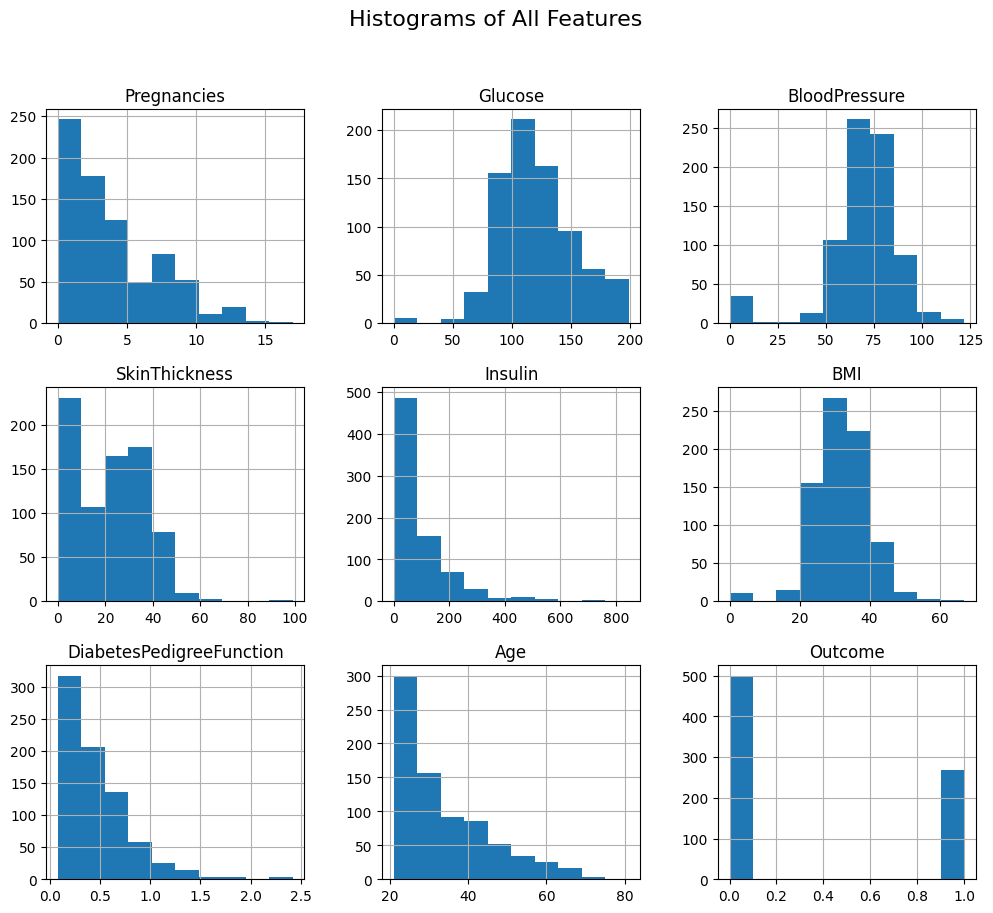

In [ ]:
df.hist(figsize=(12, 10))
plt.suptitle("Histograms of All Features", fontsize=16)
plt.show()

In [ ]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


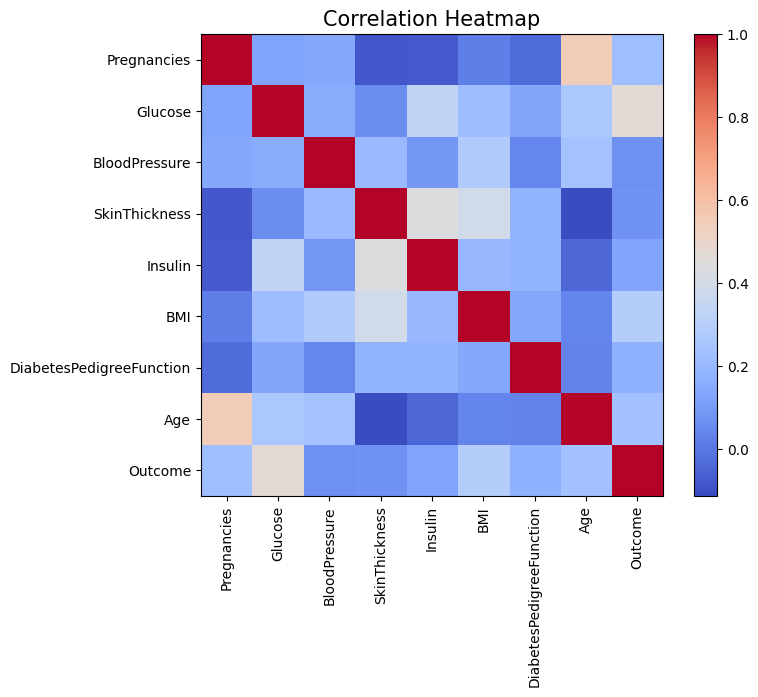

In [ ]:
plt.figure(figsize=(8, 6))
corr = df.corr()
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.title("Correlation Heatmap", fontsize=15)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

In [ ]:
diabetic = df[df['Outcome'] == 1]
non_diabetic = df[df['Outcome'] == 0]

print("\n📌 Group-wise mean comparison (Diabetic vs Non-diabetic):")
display(df.groupby('Outcome').mean())


📌 Group-wise mean comparison (Diabetic vs Non-diabetic):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


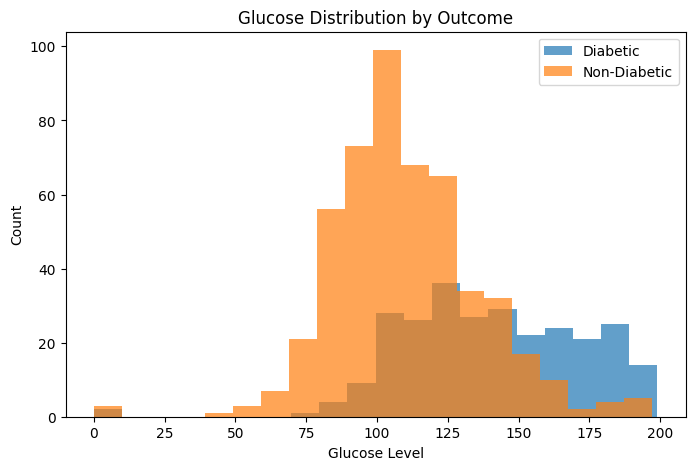

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(diabetic['Glucose'], bins=20, alpha=0.7, label="Diabetic")
plt.hist(non_diabetic['Glucose'], bins=20, alpha=0.7, label="Non-Diabetic")
plt.xlabel("Glucose Level")
plt.ylabel("Count")
plt.title("Glucose Distribution by Outcome")
plt.legend()
plt.show()

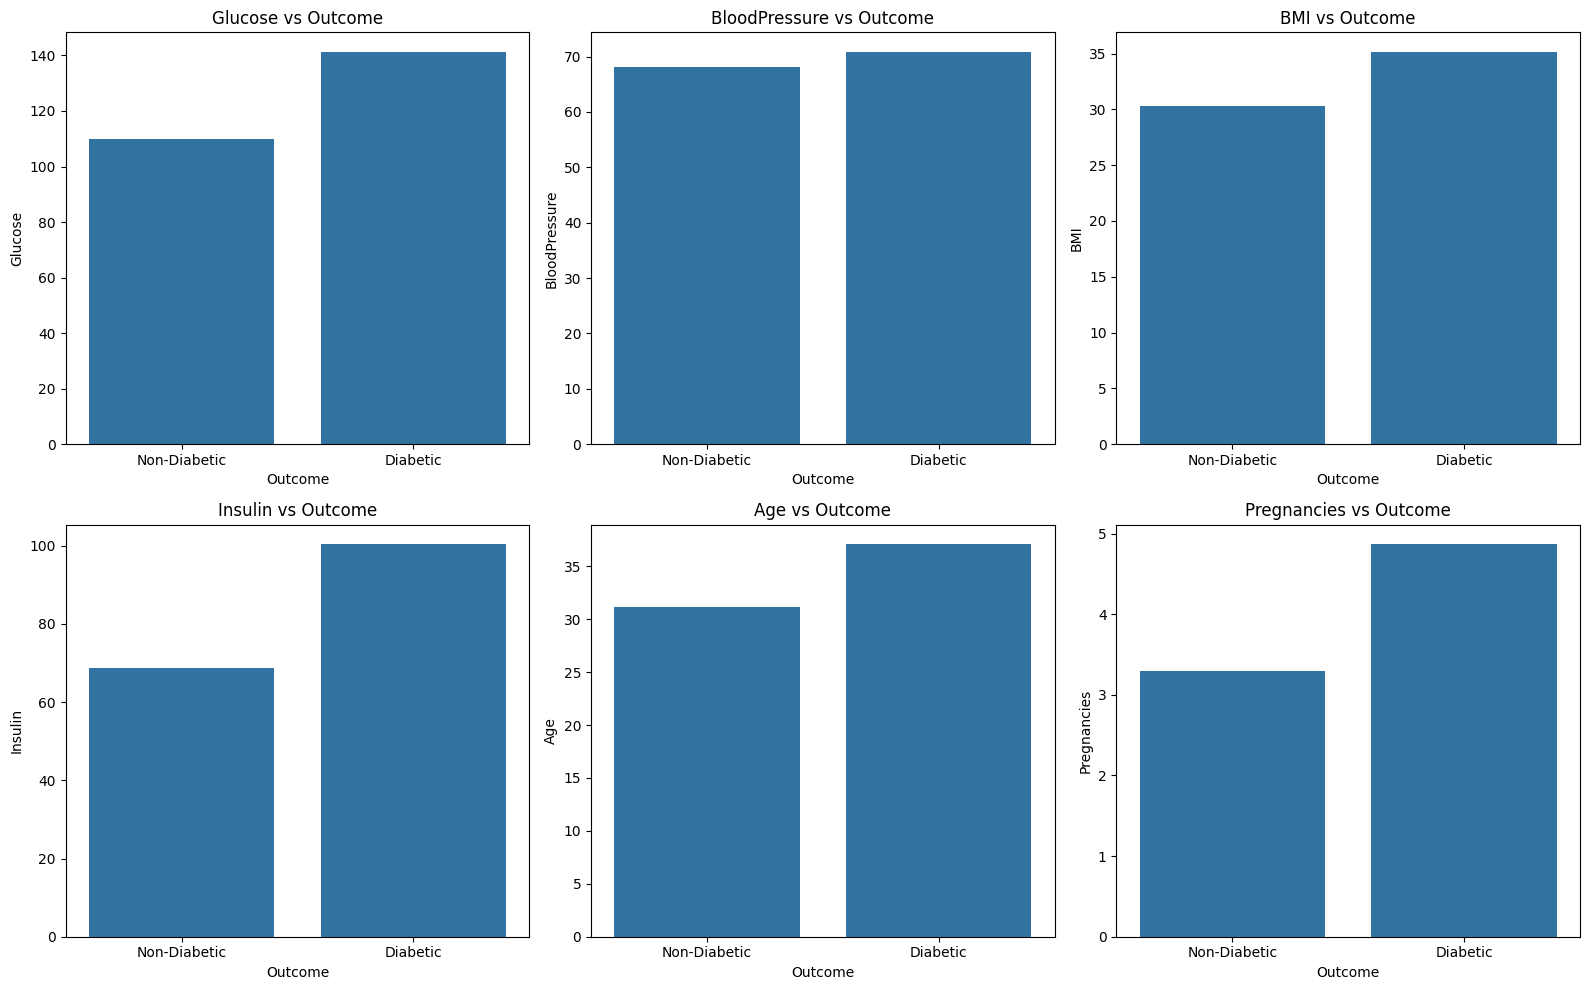

In [ ]:
grouped = df.groupby("Outcome").mean()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Assign each subplot a variable
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[0, 2]
ax4 = axes[1, 0]
ax5 = axes[1, 1]
ax6 = axes[1, 2]

sns.barplot(x=grouped.index, y=grouped["Glucose"], ax=ax1)
ax1.set_title("Glucose vs Outcome")

sns.barplot(x=grouped.index, y=grouped["BloodPressure"], ax=ax2)
ax2.set_title("BloodPressure vs Outcome")

sns.barplot(x=grouped.index, y=grouped["BMI"], ax=ax3)
ax3.set_title("BMI vs Outcome")

sns.barplot(x=grouped.index, y=grouped["Insulin"], ax=ax4)
ax4.set_title("Insulin vs Outcome")

sns.barplot(x=grouped.index, y=grouped["Age"], ax=ax5)
ax5.set_title("Age vs Outcome")

sns.barplot(x=grouped.index, y=grouped["Pregnancies"], ax=ax6)
ax6.set_title("Pregnancies vs Outcome")

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])

plt.tight_layout()
plt.show()

In [ ]:
scaler = StandardScaler()

In [ ]:
X = df.drop(columns='Outcome',axis=1)
y =df['Outcome']

In [ ]:
scaler.fit(X)

StandardScaler()

In [ ]:
X=scaler.transform(X)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(614, 8)
(154, 8)


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000,random_state=42)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Performance Metrics of Logistic Regression are:")
print('='*60)
print('Accuracy score:')
print(accuracy_score(y_test,y_pred))
print('='*60)
print("confusion matrix:")
print(confusion_matrix(y_test,y_pred))
print('='*60)
print("Classification report:")
print(classification_report(y_test,y_pred))

Performance Metrics of Logistic Regression are:
Accuracy score:
0.7532467532467533
confusion matrix:
[[79 20]
 [18 37]]
Classification report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [ ]:
from sklearn.tree import DecisionTreeClassifier
model2 = DecisionTreeClassifier(criterion='entropy',max_depth=10,random_state=42)
model2.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)

In [ ]:
y_pred_dt=model2.predict(X_test)

In [ ]:
print("Performance Metrics of Decision Tree Model are:")
print('='*60)
print('Accuracy score:')
print(accuracy_score(y_test,y_pred_dt))
print('='*60)
print("confusion matrix:")
print(confusion_matrix(y_test,y_pred_dt))
print('='*60)
print("Classification report:")
print(classification_report(y_test,y_pred_dt))

Performance Metrics of Decision Tree Model are:
Accuracy score:
0.7467532467532467
confusion matrix:
[[76 23]
 [16 39]]
Classification report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80        99
           1       0.63      0.71      0.67        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



In [ ]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100,max_depth=2,random_state=42)
model_rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=2, random_state=42)

In [ ]:
y_pred_rf= model_rf.predict(X_test)

In [ ]:
print("Performance Metrics of Random Forest Model are:")
print('='*60)
print('Accuracy score:')
print(accuracy_score(y_test,y_pred_rf))
print('='*60)
print("confusion matrix:")
print(confusion_matrix(y_test,y_pred_rf))
print('='*60)
print("Classification report:")
print(classification_report(y_test,y_pred_rf))

Performance Metrics of Random Forest Model are:
Accuracy score:
0.7922077922077922
confusion matrix:
[[92  7]
 [25 30]]
Classification report:
              precision    recall  f1-score   support

           0       0.79      0.93      0.85        99
           1       0.81      0.55      0.65        55

    accuracy                           0.79       154
   macro avg       0.80      0.74      0.75       154
weighted avg       0.80      0.79      0.78       154



<Axes: >

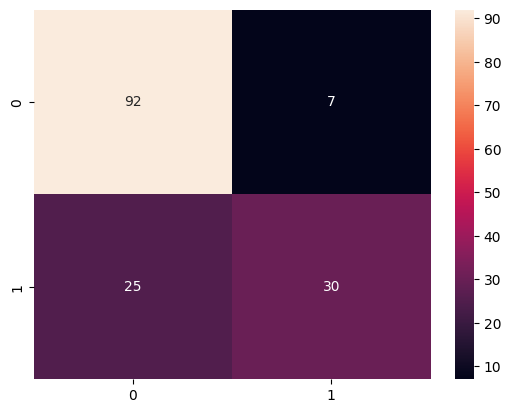

In [ ]:
cm = confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm,annot=True,fmt='d')

In [ ]:
from xgboost import XGBClassifier,plot_importance
model_xgb = XGBClassifier()
model_xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb=model_xgb.predict(X_test)

In [ ]:
print("Performance Metrics of XG Boost Classifier Model are:")
print('='*60)
print('Accuracy score:')
print(accuracy_score(y_test,y_pred_xgb))
print('='*60)
print("confusion matrix:")
print(confusion_matrix(y_test,y_pred_xgb))
print('='*60)
print("Classification report:")
print(classification_report(y_test,y_pred_xgb))

Performance Metrics of XG Boost Classifier Model are:
Accuracy score:
0.7207792207792207
confusion matrix:
[[72 27]
 [16 39]]
Classification report:
              precision    recall  f1-score   support

           0       0.82      0.73      0.77        99
           1       0.59      0.71      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.72      0.71       154
weighted avg       0.74      0.72      0.73       154



In [ ]:
from sklearn.svm import SVC
svm_model = SVC(kernel="rbf", probability=True)
svm_model.fit(X_train, y_train)

SVC(probability=True)

In [ ]:
y_pred_svm= svm_model.predict(X_test)

In [ ]:
print("Performance Metrics of SVM Model are:")
print('='*60)
print('Accuracy score:')
print(accuracy_score(y_test,y_pred_svm))
print('='*60)
print("confusion matrix:")
print(confusion_matrix(y_test,y_pred_svm))
print('='*60)
print("Classification report:")
print(classification_report(y_test,y_pred_svm))

Performance Metrics of SVM Model are:
Accuracy score:
0.7272727272727273
confusion matrix:
[[81 18]
 [24 31]]
Classification report:
              precision    recall  f1-score   support

           0       0.77      0.82      0.79        99
           1       0.63      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.70       154
weighted avg       0.72      0.73      0.72       154



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn= knn_model.predict(X_test)

In [ ]:
print("Performance Metrics of SVM Model are:")
print('='*60)
print('Accuracy score:')
print(accuracy_score(y_test,y_pred_knn))
print('='*60)
print("confusion matrix:")
print(confusion_matrix(y_test,y_pred_knn))
print('='*60)
print("Classification report:")
print(classification_report(y_test,y_pred_knn))

Performance Metrics of SVM Model are:
Accuracy score:
0.6883116883116883
confusion matrix:
[[79 20]
 [28 27]]
Classification report:
              precision    recall  f1-score   support

           0       0.74      0.80      0.77        99
           1       0.57      0.49      0.53        55

    accuracy                           0.69       154
   macro avg       0.66      0.64      0.65       154
weighted avg       0.68      0.69      0.68       154



In [ ]:
import joblib
joblib.dump(scaler, "diabetes_scaler_IT.joblib")
joblib.dump(model_rf, "diabetes_IT.joblib")

['diabetes_IT.joblib']